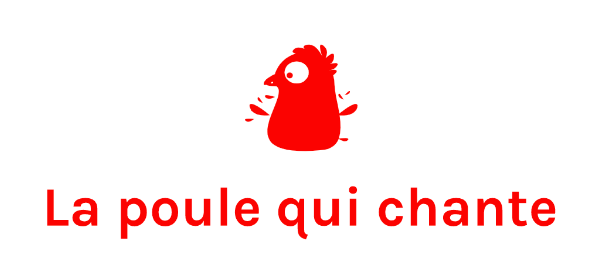

In [2]:
# import librairies and functions needed for project
import os
os.environ["OMP_NUM_THREADS"] = '1' # needed to avoid memory leak warning with K-Means in Windows environment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import StandardScaler
#from sklearn_extra.cluster import KMedoids 

# import user-defined functions
from functions import *

# use company logo colour in graphs
col = findColor('Unknown.png')

# maximise dataframe display
pd.set_option('display.max_colwidth', None)

In [3]:
# Import data & split file
data = pd.read_csv('../poule-qui-chante/export/data_final_bis.csv', encoding='latin_1',index_col=0)
x = data.values
countries = data.index
features = data.columns

# 1 - Classification ascendante hierarchique

## 1.1 - Scaling & linkage

In [4]:
std_scale = StandardScaler()
std_scale.fit(x)
x_scaled = std_scale.transform(x)
Z = shc.linkage(x_scaled, method="ward", optimal_ordering=True,
                metric='euclidean') # metric='euclidean' is implied by use of Ward method

## 1.2 - Dendrogramme

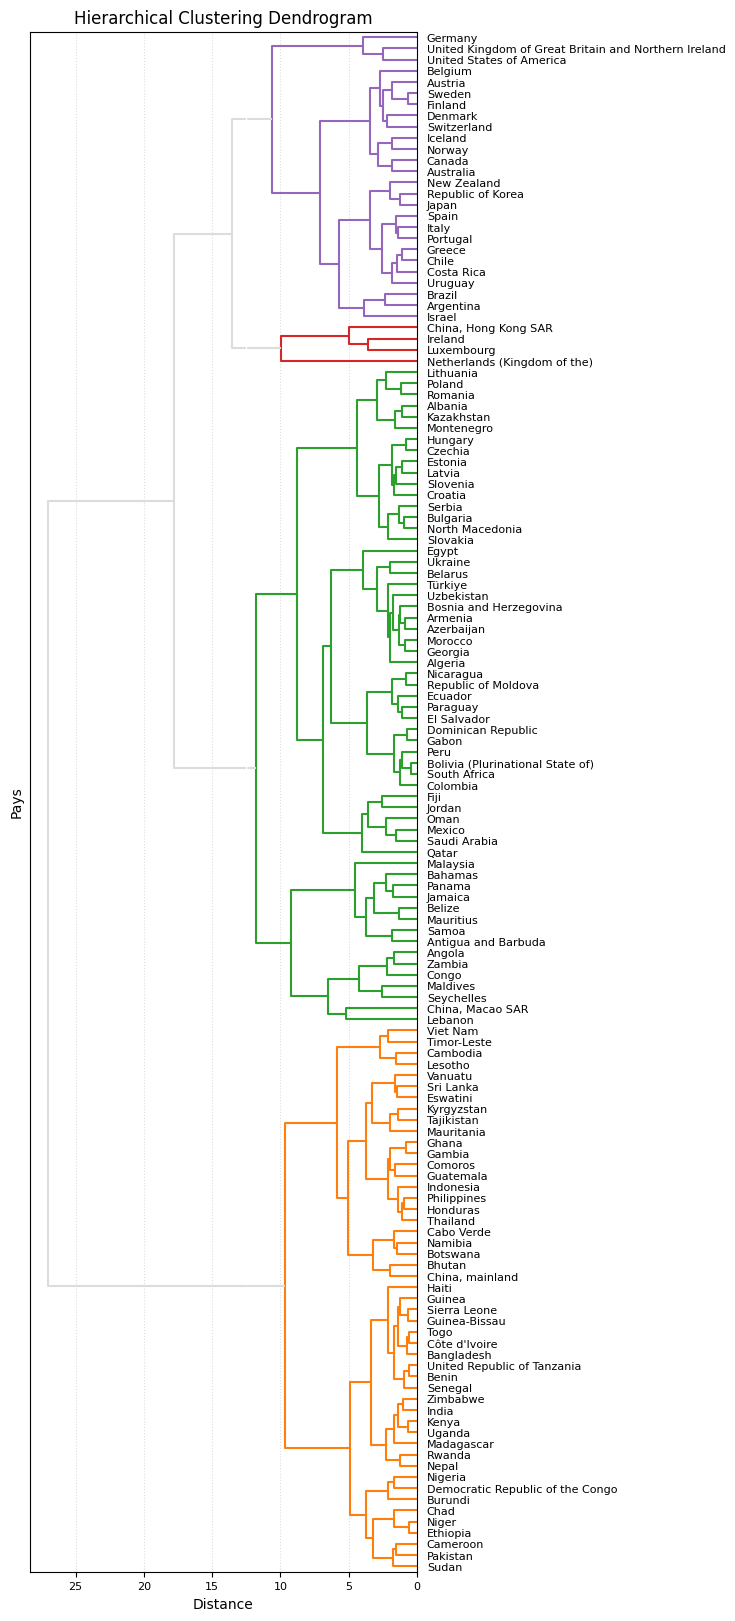

In [5]:
# plot complete vertical dendrogram
limit = 12.5
fig, ax = plt.subplots(1, 1, figsize=(5,20))
detailed_dendro = shc.dendrogram(Z, ax=ax, labels=countries, orientation = "left", color_threshold=limit,
                        leaf_rotation=0, above_threshold_color='gainsboro', leaf_font_size=6)
plt.title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Distance")
ax.set_ylabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=8)
ax.tick_params(axis='y', which='major', labelsize=8)
plt.grid(axis='x', color='gainsboro', linestyle='dotted')
plt.axvline(x=limit, c=col, lw=1, linestyle='dashed')
plt.savefig("detailed_dendro_v.png", bbox_inches='tight')
plt.show()

#### On pourrait obtenir une analyse plus fine avec 7 clusters en "coupant" le dendrogramme a une distance de 8, mais dans cette premiere etape, nous choisissons de proceder avec 4 clusters qui nous donnent une vision suffisamment detaillee des caracteristiques de nos pays.

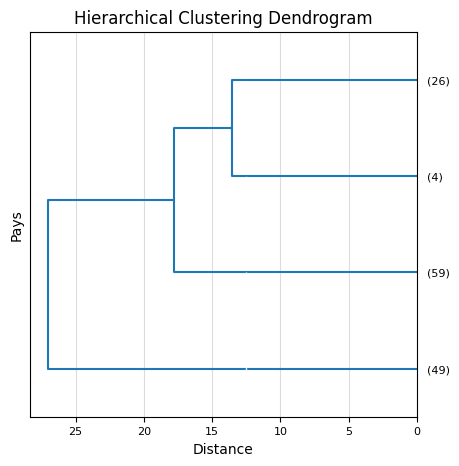

In [6]:
# plot dendrogram with 4 clusters & number of countries in each cluster
nb_clusters_dendro = 4
fig, ax = plt.subplots(1, 1, figsize=(5,5))
dendro_4clust = shc.dendrogram(Z, ax=ax, labels=countries, orientation = "left",
                         truncate_mode = 'lastp', p=nb_clusters_dendro, color_threshold=limit,
                         leaf_font_size=12, leaf_rotation=0)
plt.title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Distance")
ax.set_ylabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=8)
ax.tick_params(axis='y', which='major', labelsize=8)
plt.grid(axis='x', color='gainsboro')
plt.axvline(x=limit, c=col, lw=1, linestyle='dashed')
plt.savefig("dendro_4clust.png", bbox_inches='tight')
plt.show()

## 1.3 - Affichage des clusters

In [7]:
# print list of countries in each cluster
k = nb_clusters_dendro
dendro_clusters = shc.fcluster(Z, k, criterion='maxclust')
data_clust = pd.DataFrame({"pays" : countries, "cluster_dendro" : dendro_clusters})

for i in range(1, k+1) : 
    # select cluster
    sub_data_clust = data_clust.loc[data_clust['cluster_dendro'] == i]
    # print cluster
    print(f"cluster : {i}")
    # select country
    pays_list = sub_data_clust['pays'].values
    # create list of countries
    txt = [f"{p}" for p in pays_list]
    # add countries to list
    txt = " / ".join(txt)
    # print clusters
    print(txt)
    print("\n\n")

cluster : 1
India / Indonesia / Côte d'Ivoire / Kyrgyzstan / Kenya / Cambodia / Lesotho / Madagascar / Mauritania / Namibia / Nepal / Vanuatu / Niger / Nigeria / Bangladesh / Pakistan / Philippines / Guinea-Bissau / Timor-Leste / Bhutan / Zimbabwe / Rwanda / Senegal / Sierra Leone / Botswana / Tajikistan / Eswatini / United Republic of Tanzania / Thailand / Togo / Uganda / Viet Nam / Ethiopia / Democratic Republic of the Congo / Sudan / Burundi / Cameroon / Cabo Verde / Sri Lanka / Chad / China, mainland / Comoros / Benin / Gambia / Ghana / Guatemala / Guinea / Haiti / Honduras



cluster : 2
Armenia / Kazakhstan / Jamaica / Jordan / Latvia / Bahamas / Lebanon / Lithuania / China, Macao SAR / Malaysia / Maldives / Mauritius / Mexico / Morocco / Republic of Moldova / North Macedonia / Nicaragua / Panama / Czechia / Paraguay / Peru / Poland / Qatar / Romania / Bolivia (Plurinational State of) / Saudi Arabia / Seychelles / Slovenia / Slovakia / South Africa / Oman / Türkiye / Belize / Ukr

In [8]:
# add cluster info to original data
data_dendro = data.copy().reset_index()
data_dendro


,country,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
0,Armenia,0.643592,-7.177995,4372.939704,69.490997,2832000.0,-0.77,97.62,48.531650,7.41,15.37
1,Australia,0.850834,4.200123,55758.834562,44.039528,-1104000.0,0.86,108.73,74.880290,21.25,10.72
2,India,0.344426,-6.144681,1910.271668,37.870998,2740000.0,-0.84,64.82,15.347798,1.44,5.69
3,Indonesia,0.561063,-5.365475,3853.702895,33.190590,31557000.0,-0.46,54.92,26.853527,6.04,8.44
4,Ireland,0.624440,7.228912,87615.893087,239.951034,4922000.0,0.97,108.69,72.767200,18.67,9.05
...,...,...,...,...,...,...,...,...,...,...,...
133,Honduras,0.560500,-6.148939,2307.614874,85.753746,7236000.0,-0.45,60.38,20.549467,9.33,10.82
134,"China, Hong Kong SAR",1.007666,-4.994466,46052.080236,351.664001,1685000.0,0.06,124.06,107.822830,24.04,6.39
135,Hungary,0.709964,-3.921623,16254.084292,157.258362,-46232000.0,0.84,85.48,50.607360,7.52,15.55
136,Croatia,0.599104,-7.456421,14620.621102,90.807716,-2761000.0,0.61,88.60,56.204975,5.62,14.42


In [9]:
data_clust

,pays,cluster_dendro
0,Armenia,2
1,Australia,4
2,India,1
3,Indonesia,1
4,Ireland,3
...,...,...
133,Honduras,1
134,"China, Hong Kong SAR",3
135,Hungary,2
136,Croatia,2


In [10]:
clusters = pd.merge(data_dendro, data_clust, how='left', left_on='country', right_on='pays' ).drop(['pays'], axis=1)


clusterbis = clusters.copy()
clusterbis['cluster_dendro'] = clusterbis['cluster_dendro'].astype(str)
clusterbis = clusterbis.drop(columns=['country'])


In [11]:
# display clusters mean values
clusters_dendro_avg = clusterbis.groupby('cluster_dendro').mean()
clusters_dendro_avg

,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
cluster_dendro,,,,,,,,,,
1,0.399372,-1.311030,2137.201675,60.923659,4.206286e+06,-5.220408e-01,61.067143,18.179642,3.269796,7.417551
2,0.658561,-10.341523,10207.789091,86.091278,2.878458e+06,1.881734e-18,81.820678,42.592357,12.269322,15.031525
3,0.851631,2.019496,75854.101361,278.303677,9.451950e+07,7.675000e-01,110.120000,79.257475,13.512500,7.785000
4,0.829971,-4.188403,39916.867437,66.192737,-2.969681e+07,6.353846e-01,98.148462,64.040877,12.806538,9.489615


/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/331865404.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#ffffff'` for the same effect.

  dendro_box_gdp = sns.boxplot(data=clusters, x="cluster_dendro", y="gdp_per_cap_US$", hue="cluster_dendro", flierprops={"marker": "1"},


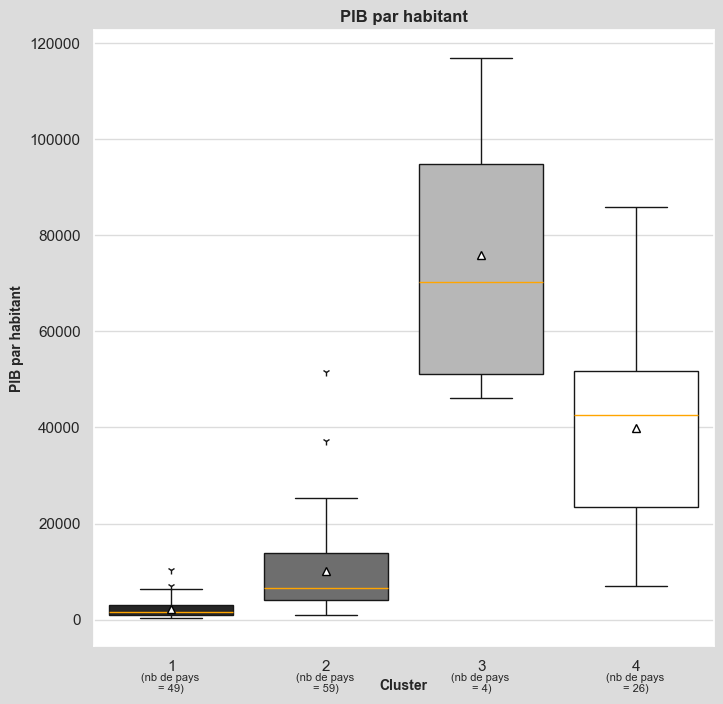

In [12]:
# plot clusters against gdp per capita on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
dendro_box_gdp = sns.boxplot(data=clusters, x="cluster_dendro", y="gdp_per_cap_US$", hue="cluster_dendro", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color=col, showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel('PIB par habitant', fontweight='bold', fontsize=10)
plt.title('PIB par habitant', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
nb_pays = clusters.groupby('cluster_dendro')['country'].count().reset_index()
plt.text(0, -11000,"(nb de pays \n= {})".format(nb_pays.iloc[0, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)  
plt.text(1, -11000,"(nb de pays \n= {})".format(nb_pays.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -11000,"(nb de pays \n= {})".format(nb_pays.iloc[2, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(3, -11000,"(nb de pays \n= {})".format(nb_pays.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("dendro_box_gdp.png", bbox_inches='tight')
plt.show()

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/3881377034.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#ffffff'` for the same effect.

  dendro_box_gdp_growth = sns.boxplot(data=clusters, x="cluster_dendro", y="gdp_growth_%", hue="cluster_dendro", flierprops={"marker": "1"},


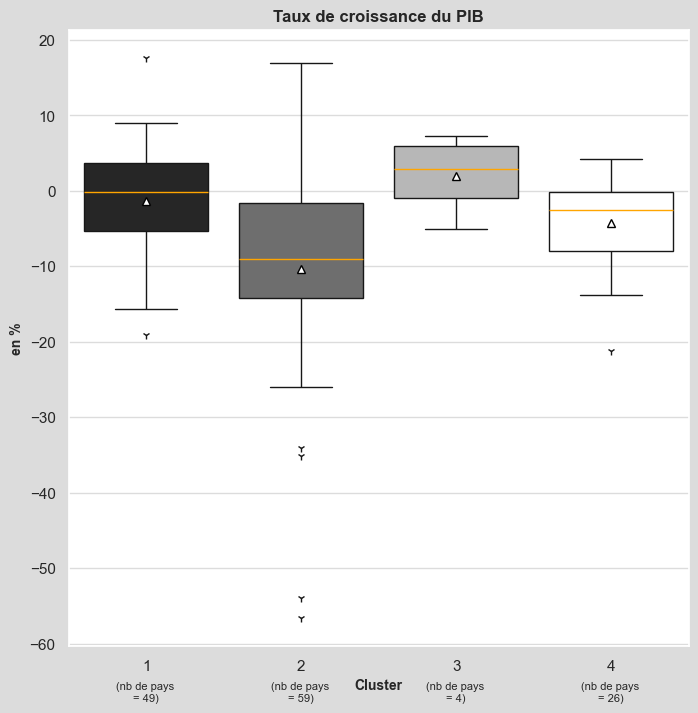

In [13]:
# plot clusters against gdp growth on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
dendro_box_gdp_growth = sns.boxplot(data=clusters, x="cluster_dendro", y="gdp_growth_%", hue="cluster_dendro", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color=col, showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel('en %', fontweight='bold', fontsize=10)
plt.title('Taux de croissance du PIB', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
plt.text(0, -65,"(nb de pays \n= {})".format(nb_pays.iloc[0, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)  
plt.text(1, -65,"(nb de pays \n= {})".format(nb_pays.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -65,"(nb de pays \n= {})".format(nb_pays.iloc[2, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(3, -65,"(nb de pays \n= {})".format(nb_pays.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("dendro_box_gdp_growth.png", bbox_inches='tight')
plt.show()

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/977179654.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#ffffff'` for the same effect.

  dendro_box_trade = sns.boxplot(data=clusters, x="cluster_dendro", y="trade_%_gdp", hue="cluster_dendro", flierprops={"marker": "1"},


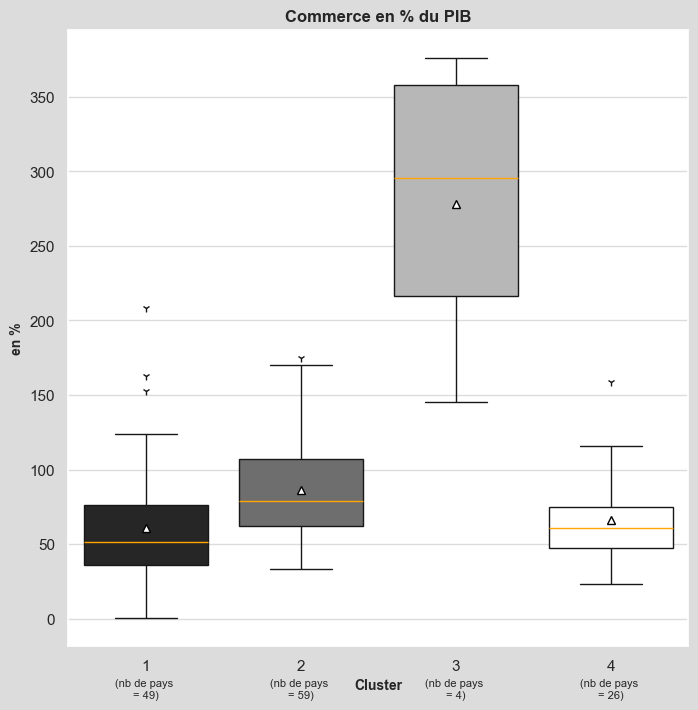

In [14]:
# plot clusters against trade as % gdp on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
dendro_box_trade = sns.boxplot(data=clusters, x="cluster_dendro", y="trade_%_gdp", hue="cluster_dendro", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color=col, showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel('en %', fontweight='bold', fontsize=10)
plt.title('Commerce en % du PIB', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
plt.text(0, -40,"(nb de pays \n= {})".format(nb_pays.iloc[0, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)  
plt.text(1, -40,"(nb de pays \n= {})".format(nb_pays.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -40,"(nb de pays \n= {})".format(nb_pays.iloc[2, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(3, -40,"(nb de pays \n= {})".format(nb_pays.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("dendro_box_trade.png", bbox_inches='tight')
plt.show()

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/2166319126.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#ffffff'` for the same effect.

  dendro_box_net_M = sns.boxplot(data=clusters, x="cluster_dendro", y="net_imports_poultry_US$", hue="cluster_dendro", flierprops={"marker": "1"},


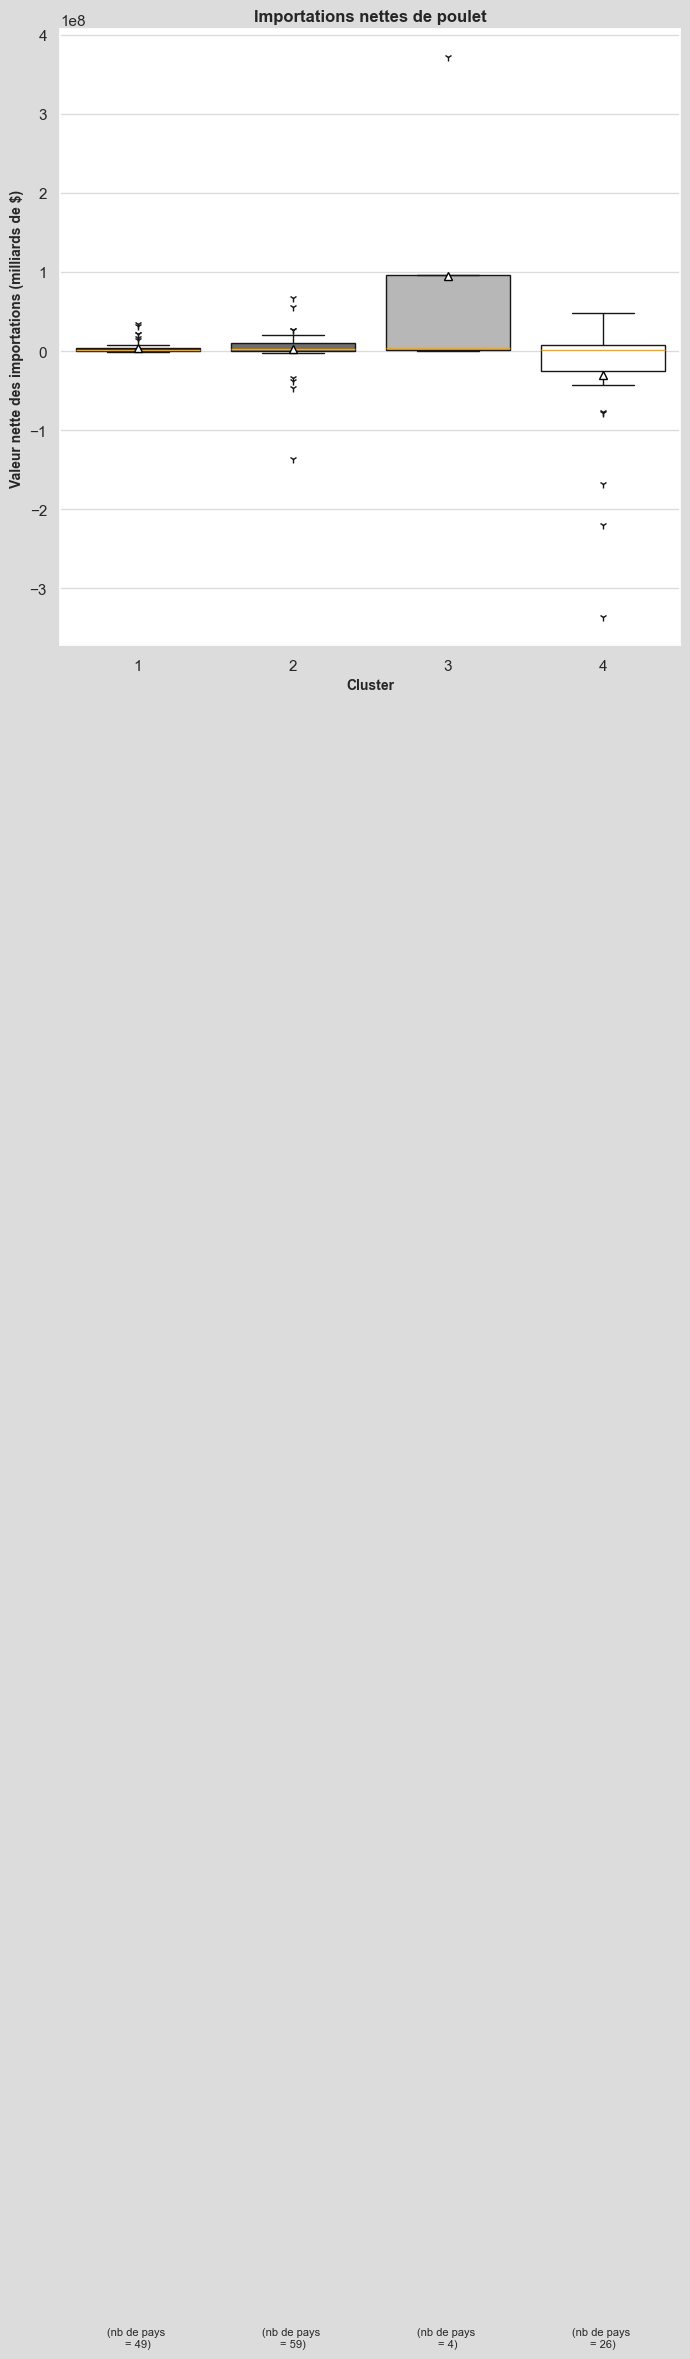

In [15]:
# plot clusters against net poultry imports on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
dendro_box_net_M = sns.boxplot(data=clusters, x="cluster_dendro", y="net_imports_poultry_US$", hue="cluster_dendro", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color=col, showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel("Valeur nette des importations (milliards de $)", fontweight='bold', fontsize=10)
plt.title('Importations nettes de poulet', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
plt.text(0, -2500000000,"(nb de pays \n= {})".format(nb_pays.iloc[0, 1]), horizontalalignment='center',
        verticalalignment='top', fontsize=8)  
plt.text(1, -2500000000,"(nb de pays \n= {})".format(nb_pays.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -2500000000,"(nb de pays \n= {})".format(nb_pays.iloc[2, 1]), horizontalalignment='center',
        verticalalignment='top', fontsize=8)
plt.text(3, -2500000000,"(nb de pays \n= {})".format(nb_pays.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("dendro_box_net_M.png", bbox_inches='tight')
plt.show()

# 2 - K-means clustering

## 2.1 - Centrage & reduction des donnees

In [16]:
# center & reduce data
x = data.copy()
std_scaler = StandardScaler()
std_scaler.fit(x)
x_scaled = std_scaler.transform(x)

## 2.2 - Determination du nombre optimal de clusters

### Methode du coude

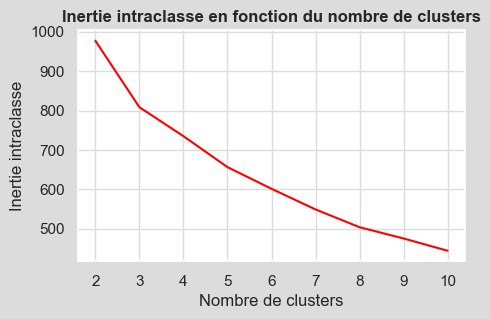

In [17]:
# test for number of clusters between 2 and number of columns in data (=11)
k_list = range(2, data.shape[1]+1)

# create data for within-cluster sum of squares for K-means clusters between 2 and 11
wcss = []

for i in k_list :
    kmeans_wcss = KMeans(n_clusters=i, init='k-means++', copy_x=True, algorithm='elkan', n_init=30,max_iter=300,verbose=0)
    kmeans_wcss.fit(x_scaled)
    wcss.append(kmeans_wcss.inertia_)

# plot wcss curve
fig, ax = plt.subplots(1,1,figsize=(5,3))
ax.set_ylabel("Inertie intraclasse")
ax.set_xlabel("Nombre de clusters")
ax.set_title("Inertie intraclasse en fonction du nombre de clusters", fontsize=12, fontweight='bold')
ax = plt.plot(k_list, wcss, color='red')
plt.xticks(np.arange(min(k_list), max(k_list)+1, 1.0))
plt.grid(axis='both', color='gainsboro')
plt.savefig("kmeans_coude.png", bbox_inches='tight')
plt.show()

#### La courbe ne comporte pas de "coude" evident.

### Silhouette score

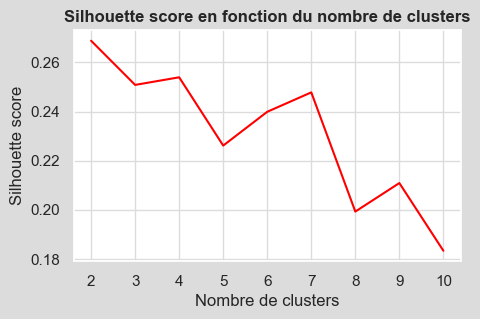

In [18]:
# calculate score for number of K-means clusters between 2 and 11
silhouette = []

for j in k_list :
    kmeans_silh = KMeans(n_clusters=j, init='k-means++', copy_x=True, algorithm='elkan', n_init=30,max_iter=300, verbose=0)
    kmeans_silh.fit(x_scaled)
    silh = silhouette_score(x_scaled, kmeans_silh.labels_)
    silhouette.append(silh)
    
# plot silhouette score curve
fig, ax = plt.subplots(1,1,figsize=(5,3))
ax.set_ylabel("Silhouette score")
ax.set_xlabel("Nombre de clusters")
ax.set_title("Silhouette score en fonction du nombre de clusters", fontsize=12, fontweight='bold')
ax = plt.plot(k_list, silhouette, color='red')
plt.xticks(np.arange(min(k_list), max(k_list)+1, 1.0))
plt.grid(axis='both', color='gainsboro')
plt.savefig("silhouette.png", bbox_inches='tight')
plt.show()

#### Le score silhouette est maximal avec 2 clusters mais semble indiquer 4 ou 6 clusters comme acceptables.

### Indice de Davies-Bouldin

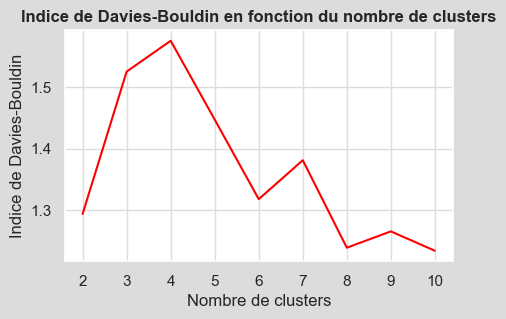

In [19]:
# calculate score for number of K-means clusters between 2 and 11
dav_bould = []

for h in k_list :
    kmeans_db = KMeans(n_clusters=h, init='k-means++', copy_x=True, algorithm='elkan', n_init=30,max_iter=300,verbose=0)
    kmeans_db.fit(x_scaled)
    d_b = davies_bouldin_score(x_scaled, kmeans_db.labels_)
    dav_bould.append(d_b)

# plot Davies-Bouldin score curve
fig, ax = plt.subplots(1,1,figsize=(5,3))
ax.set_ylabel("Indice de Davies-Bouldin")
ax.set_xlabel("Nombre de clusters")
ax.set_title("Indice de Davies-Bouldin en fonction du nombre de clusters", fontsize=12, fontweight='bold')
ax = plt.plot(k_list, dav_bould, color='red')
plt.xticks(np.arange(min(k_list), max(k_list)+1, 1.0))
plt.grid(axis='both', color='gainsboro')
plt.savefig("davies_bouldin.png", bbox_inches='tight')
plt.show()

#### Le score de Davies-Bouldin est maximal pour 3 clusters et similaire pour 4 ou 5 clusters.
#### Nous procederons donc au clustering sur 4, 5 et 6 clusters afin de comparer les resultats et de decider du nombre de clusters a conserver en fonction de l'ampleur des differences observees.

## 2.3 - K-means clustering sur 4, 5 et 6 clusters

### K-means sur 6 clusters

In [20]:
# run K-means
kmeans_6 = KMeans(n_clusters=6, init='k-means++', copy_x=True, algorithm='elkan', n_init=30, max_iter=300, verbose=0)
kmeans_6.fit(x_scaled)
labels_6 = kmeans_6.labels_
# add cluster number to each country in clusters dataframe
clusters['cluster_km_6'] = (kmeans_6.labels_ + 1)

# print list of countries in each cluster
cluster_6_1 = clusters.loc[clusters['cluster_km_6'] == 1]['country'].tolist()
print('Pays du 1er cluster - ', len(cluster_6_1),'pays:\n', cluster_6_1)
cluster_6_2 = clusters.loc[clusters['cluster_km_6'] == 2]['country'].tolist()
print('Pays du 2eme cluster - ', len(cluster_6_2),'pays:\n', cluster_6_2)
cluster_6_3 = clusters.loc[clusters['cluster_km_6'] == 3]['country'].tolist()
print('Pays du 3eme cluster - ', len(cluster_6_3),'pays:\n', cluster_6_3)
cluster_6_4 = clusters.loc[clusters['cluster_km_6'] == 4]['country'].tolist()
print('Pays du 4eme cluster - ', len(cluster_6_4),'pays:\n', cluster_6_4)
cluster_6_5 = clusters.loc[clusters['cluster_km_6'] == 5]['country'].tolist()
print('Pays du 5eme cluster - ', len(cluster_6_5),'pays:\n', cluster_6_5)
cluster_6_6 = clusters.loc[clusters['cluster_km_6'] == 6]['country'].tolist()
print('Pays du 6eme cluster - ', len(cluster_6_6),'pays:\n', cluster_6_6)

Pays du 1er cluster -  36 pays:
 ['Armenia', 'Kazakhstan', 'Jordan', 'Kyrgyzstan', 'Latvia', 'Mauritania', 'Morocco', 'Republic of Moldova', 'North Macedonia', 'Nicaragua', 'Paraguay', 'Poland', 'Bhutan', 'Romania', 'Slovenia', 'Slovakia', 'Botswana', 'Türkiye', 'Ukraine', 'Uzbekistan', 'Viet Nam', 'Bulgaria', 'Serbia', 'Montenegro', 'Albania', 'Algeria', 'China, mainland', 'Azerbaijan', 'Belarus', 'Egypt', 'El Salvador', 'Estonia', 'Georgia', 'Bosnia and Herzegovina', 'Hungary', 'Croatia']
Pays du 2eme cluster -  21 pays:
 ['Australia', 'Israel', 'Italy', 'Austria', 'Japan', 'Republic of Korea', 'Lithuania', 'New Zealand', 'Norway', 'Czechia', 'Portugal', 'Spain', 'Sweden', 'Switzerland', 'Uruguay', 'Belgium', 'Canada', 'Denmark', 'Finland', 'Greece', 'Iceland']
Pays du 3eme cluster -  44 pays:
 ['India', 'Indonesia', "Côte d'Ivoire", 'Kenya', 'Cambodia', 'Lesotho', 'Madagascar', 'Namibia', 'Nepal', 'Vanuatu', 'Niger', 'Nigeria', 'Bangladesh', 'Pakistan', 'Philippines', 'Guinea-Bissau

### K-means sur 5 clusters

In [21]:
# run K-means
kmeans_5 = KMeans(n_clusters=5, init='k-means++', copy_x=True, algorithm='elkan', n_init=30, max_iter=300, verbose=0)
kmeans_5.fit(x_scaled)
labels_5 = kmeans_5.labels_
# add cluster number to each country in clusters dataframe
clusters['cluster_km_5'] = (kmeans_5.labels_ + 1)

# print list of countries in each cluster
cluster_5_1 = clusters.loc[clusters['cluster_km_5'] == 1]['country'].tolist()
print('Pays du 1er cluster - ', len(cluster_5_1),'pays:\n', cluster_5_1)
cluster_5_2 = clusters.loc[clusters['cluster_km_5'] == 2]['country'].tolist()
print('Pays du 2eme cluster - ', len(cluster_5_2),'pays:\n', cluster_5_2)
cluster_5_3 = clusters.loc[clusters['cluster_km_5'] == 3]['country'].tolist()
print('Pays du 3eme cluster - ', len(cluster_5_3),'pays:\n', cluster_5_3)
cluster_5_4 = clusters.loc[clusters['cluster_km_5'] == 4]['country'].tolist()
print('Pays du 4eme cluster - ', len(cluster_5_4),'pays:\n', cluster_5_4)
cluster_5_5 = clusters.loc[clusters['cluster_km_5'] == 5]['country'].tolist()
print('Pays du 5eme cluster - ', len(cluster_5_5),'pays:\n', cluster_5_5)

Pays du 1er cluster -  22 pays:
 ['Australia', 'Ireland', 'Israel', 'Italy', 'Austria', 'Japan', 'Republic of Korea', 'Lithuania', 'Netherlands (Kingdom of the)', 'New Zealand', 'Norway', 'Portugal', 'Spain', 'Sweden', 'Switzerland', 'Belgium', 'Luxembourg', 'Canada', 'Denmark', 'Finland', 'China, Hong Kong SAR', 'Iceland']
Pays du 2eme cluster -  31 pays:
 ['Jamaica', 'Bahamas', 'Lebanon', 'China, Macao SAR', 'Malaysia', 'Maldives', 'Mauritius', 'Mexico', 'Panama', 'Peru', 'Qatar', 'Bolivia (Plurinational State of)', 'Saudi Arabia', 'Seychelles', 'South Africa', 'Brazil', 'Oman', 'Belize', 'Uruguay', 'Samoa', 'Cabo Verde', 'Chile', 'Colombia', 'Congo', 'Costa Rica', 'Dominican Republic', 'Ecuador', 'Fiji', 'Gabon', 'Antigua and Barbuda', 'Argentina']
Pays du 3eme cluster -  47 pays:
 ['India', 'Indonesia', "Côte d'Ivoire", 'Kenya', 'Cambodia', 'Lesotho', 'Madagascar', 'Mauritania', 'Namibia', 'Nepal', 'Vanuatu', 'Niger', 'Nigeria', 'Bangladesh', 'Pakistan', 'Philippines', 'Guinea-Biss

### K-means sur 4 clusters

In [22]:
# run K-means
kmeans_4 = KMeans(n_clusters=nb_clusters_dendro, init='k-means++', copy_x=True, algorithm='elkan', n_init=30, max_iter=300,
                  verbose=0)
kmeans_4.fit(x_scaled)
labels_4 = kmeans_4.labels_
# add cluster number to each country in clusters dataframe
clusters['cluster_km_4'] = (kmeans_4.labels_ + 1)

# print list of countries in each cluster
cluster_4_1 = clusters.loc[clusters['cluster_km_4'] == 1]['country'].tolist()
print('Pays du 1er cluster - ', len(cluster_4_1),'pays:\n', cluster_4_1)
cluster_4_2 = clusters.loc[clusters['cluster_km_4'] == 2]['country'].tolist()
print('Pays du 2eme cluster - ', len(cluster_4_2),'pays:\n', cluster_4_2)
cluster_4_3 = clusters.loc[clusters['cluster_km_4'] == 3]['country'].tolist()
print('Pays du 3eme cluster - ', len(cluster_4_3),'pays:\n', cluster_4_3)
cluster_4_4 = clusters.loc[clusters['cluster_km_4'] == 4]['country'].tolist()
print('Pays du 4eme cluster - ', len(cluster_4_4),'pays:\n', cluster_4_4)

Pays du 1er cluster -  55 pays:
 ['Armenia', 'Kazakhstan', 'Jamaica', 'Jordan', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Mauritius', 'Mexico', 'Morocco', 'Republic of Moldova', 'North Macedonia', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Romania', 'Bolivia (Plurinational State of)', 'Saudi Arabia', 'Seychelles', 'Slovenia', 'Slovakia', 'Botswana', 'South Africa', 'Oman', 'Türkiye', 'Belize', 'Ukraine', 'Uzbekistan', 'Samoa', 'Bulgaria', 'Serbia', 'Montenegro', 'Albania', 'Cabo Verde', 'Algeria', 'Chile', 'China, mainland', 'Colombia', 'Costa Rica', 'Azerbaijan', 'Dominican Republic', 'Belarus', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Gabon', 'Antigua and Barbuda', 'Bosnia and Herzegovina', 'Hungary', 'Croatia']
Pays du 2eme cluster -  6 pays:
 ['Ireland', 'Netherlands (Kingdom of the)', 'Switzerland', 'Belgium', 'Luxembourg', 'China, Hong Kong SAR']
Pays du 3eme cluster -  49 pays:
 ['India', 'Indonesia', "Côte d'Ivoire", 'Kenya', 'Cambodia', 'Lesotho',

#### Avec 4, 5 ou 6 clusters, le Bresil et les USA appartiennent a un cluster separe du fait de leurs statut de grand exportateur net de poulet. Ce resultat s'observe egalement sur le haut du dendrogramme.
#### Dans le K-means a 6 clusters, 'China, Hong Kong SAR', 'Ireland', 'Luxembourg' et 'Malta' sont separes du cluster qui contient les autres pays europeens. Leur statut de hub financier leur confere un PIB par habitant singulier mais qui ne justifie pas une analyse dans un cluster separe pour nos besoins.
#### Les clusters produits par la CAH et le K-means sont tres proches mais neanmoins pas identiques : leur ordre et leur composition sont differentes, et ce resultat est normal, les deux methodes n'aboutissant generalement pas a des resultats identiques. Cependant, si on se refere aux differents boxplots, on constate que les caracteristiques generiques des groupes constitues en termes de PIB par habitant, consommation de volaille, importations nettes etc... sont dans l'ensemble conservees.
#### Nous choisissons donc d'analyser nos donnees selon 4 clusters, afin de les comparer plus facilement aux resultats de la CAH. Analysons leurs caracteristiques:

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/887661388.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  km_4_box_gdp = sns.boxplot(data=clusters, x="cluster_km_4", y="gdp_per_cap_US$", hue="cluster_km_4", flierprops={"marker": "1"},


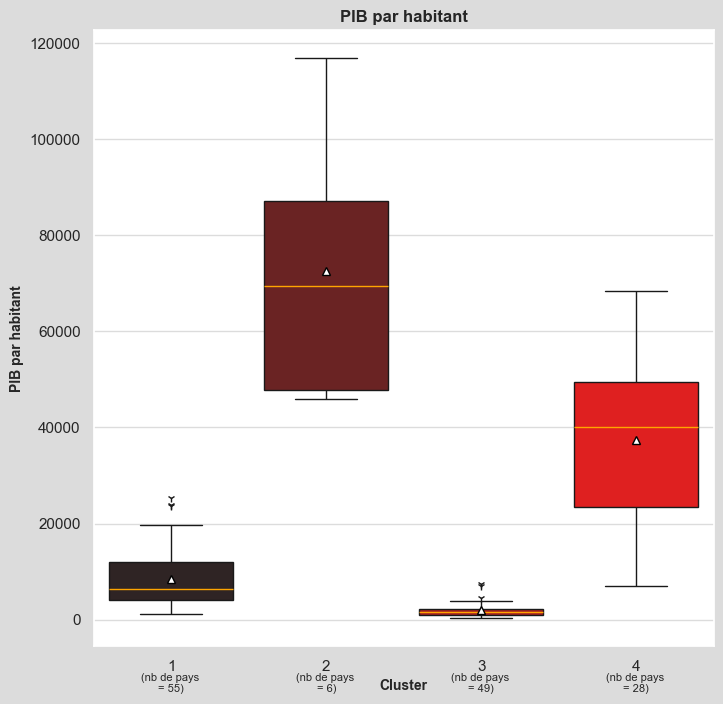

In [23]:
# plot clusters against gdp per capita on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
km_4_box_gdp = sns.boxplot(data=clusters, x="cluster_km_4", y="gdp_per_cap_US$", hue="cluster_km_4", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color='red', showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel('PIB par habitant', fontweight='bold', fontsize=10)
plt.title('PIB par habitant', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
nb_pays_2 = clusters.groupby('cluster_km_4')['country'].count().reset_index()
plt.text(0, -11000,"(nb de pays \n= {})".format(nb_pays_2.iloc[0, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)  
plt.text(1, -11000,"(nb de pays \n= {})".format(nb_pays_2.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -11000,"(nb de pays \n= {})".format(nb_pays_2.iloc[2, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(3, -11000,"(nb de pays \n= {})".format(nb_pays_2.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("km_4_box_gdp.png", bbox_inches='tight')
plt.show()

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/2901717884.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  km_4_box_gdp_growth = sns.boxplot(data=clusters, x="cluster_km_4", y="gdp_growth_%", hue="cluster_km_4", flierprops={"marker": "1"},


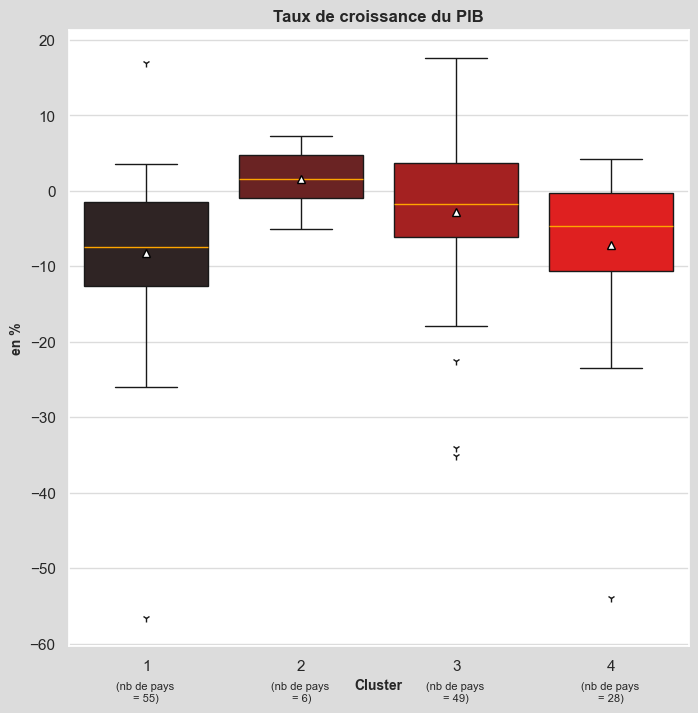

In [24]:
# plot clusters against gdp growth on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
km_4_box_gdp_growth = sns.boxplot(data=clusters, x="cluster_km_4", y="gdp_growth_%", hue="cluster_km_4", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color='red', showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel('en %', fontweight='bold', fontsize=10)
plt.title('Taux de croissance du PIB', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
plt.text(0, -65,"(nb de pays \n= {})".format(nb_pays_2.iloc[0, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)  
plt.text(1, -65,"(nb de pays \n= {})".format(nb_pays_2.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -65,"(nb de pays \n= {})".format(nb_pays_2.iloc[2, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(3, -65,"(nb de pays \n= {})".format(nb_pays_2.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("km_4_box_gdp_growth.png", bbox_inches='tight')
plt.show()

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/1994188290.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  km_4_box_trade = sns.boxplot(data=clusters, x="cluster_km_4", y="trade_%_gdp", hue="cluster_km_4", flierprops={"marker": "1"},


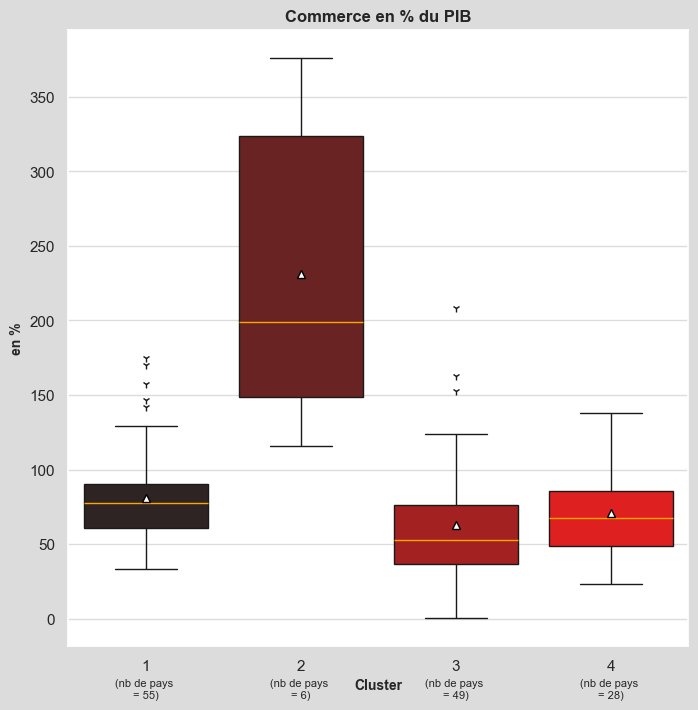

In [25]:
# plot clusters against trade as % gdp on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
km_4_box_trade = sns.boxplot(data=clusters, x="cluster_km_4", y="trade_%_gdp", hue="cluster_km_4", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color='red', showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel('en %', fontweight='bold', fontsize=10)
plt.title('Commerce en % du PIB', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
plt.text(0, -40,"(nb de pays \n= {})".format(nb_pays_2.iloc[0, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)  
plt.text(1, -40,"(nb de pays \n= {})".format(nb_pays_2.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -40,"(nb de pays \n= {})".format(nb_pays_2.iloc[2, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(3, -40,"(nb de pays \n= {})".format(nb_pays_2.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("km_4_box_trade.png", bbox_inches='tight')
plt.show()

/var/folders/v2/_0pssf4s1yq9qc7hcc34x81c0000gn/T/ipykernel_12314/2657877074.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  km_4_box_net_M = sns.boxplot(data=clusters, x="cluster_km_4", y="net_imports_poultry_US$", hue="cluster_km_4", flierprops={"marker": "1"},


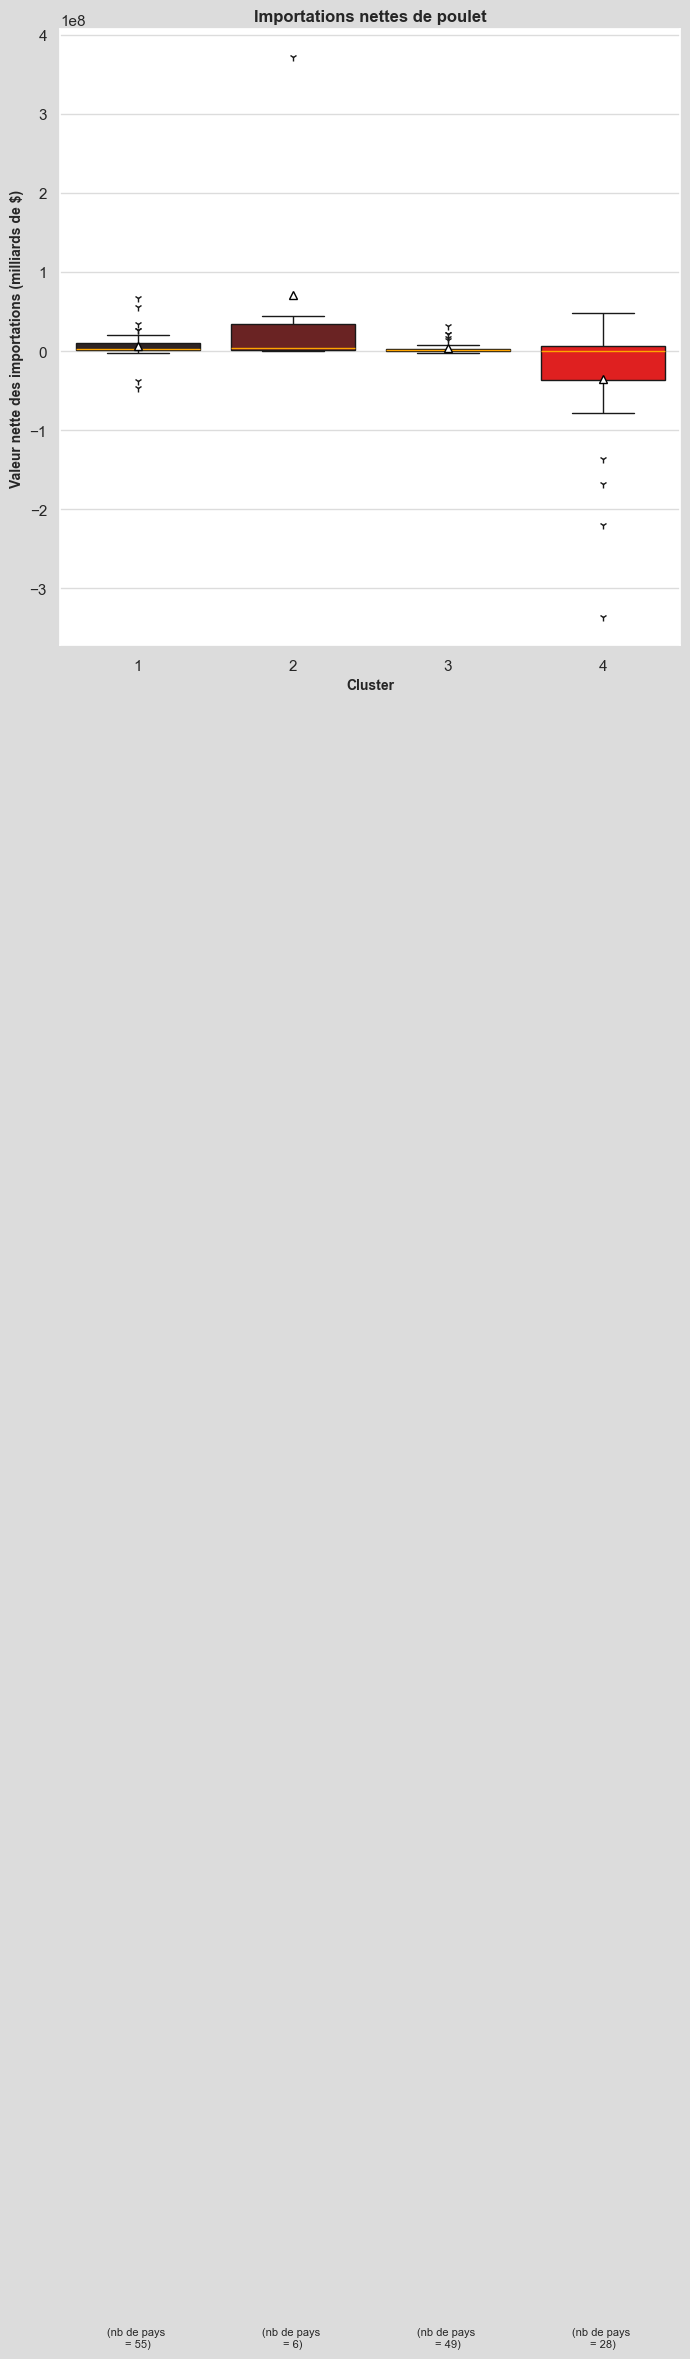

In [26]:
# plot clusters against net poultry imports on a box plot
sns.set(rc={'figure.figsize':(8,8), 'axes.facecolor':'white', 'figure.facecolor':'gainsboro'})
km_4_box_net_M = sns.boxplot(data=clusters, x="cluster_km_4", y="net_imports_poultry_US$", hue="cluster_km_4", flierprops={"marker": "1"},
            medianprops={"color" : "orange"}, meanprops={"markerfacecolor":"white", "markeredgecolor":"black"},
            orient="v", color='red', showmeans=True, dodge=False)
plt.xlabel('Cluster', fontweight='bold', fontsize=10)
plt.ylabel("Valeur nette des importations (milliards de $)", fontweight='bold', fontsize=10)
plt.title('Importations nettes de poulet', fontweight='bold', fontsize=12)
plt.legend('', frameon=False)
plt.grid(axis='y', color='gainsboro')

# add number of countries in each cluster
# nb_pays = clusters.groupby('cluster')['country'].count().reset_index()
plt.text(0, -2500000000,"(nb de pays \n= {})".format(nb_pays_2.iloc[0, 1]), horizontalalignment='center',
        verticalalignment='top', fontsize=8)  
plt.text(1, -2500000000,"(nb de pays \n= {})".format(nb_pays_2.iloc[1, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.text(2, -2500000000,"(nb de pays \n= {})".format(nb_pays_2.iloc[2, 1]), horizontalalignment='center',
        verticalalignment='top', fontsize=8)
plt.text(3, -2500000000,"(nb de pays \n= {})".format(nb_pays_2.iloc[3, 1]), horizontalalignment='center',
         verticalalignment='top', fontsize=8)
plt.savefig("km_4_box_net_M.png", bbox_inches='tight')
plt.show()

### Analyse des centroides

In [27]:
centroids_4 = kmeans_4.cluster_centers_
centroids_km_4 = pd.DataFrame(centroids_4)
centroids_km_4.columns = features
centroids_km_4

,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
0,0.210392,-0.242263,-0.305149,0.038188,0.126784,0.027074,0.259789,0.127269,0.341787,0.862124
1,1.138906,0.683495,2.788409,2.921849,1.337657,1.051482,1.318491,1.622355,0.290239,-0.673141
2,-0.954726,0.270397,-0.623407,-0.309203,0.066557,-0.666824,-0.968901,-0.996398,-0.839209,-0.809850
3,1.013449,-0.143783,1.092846,-0.160018,-0.652156,0.888443,0.902743,1.146057,0.735055,-0.131977


In [28]:
# plot polar chart centroids
categories = centroids_km_4.columns
fig = go.Figure()
fig.add_trace(go.Scatterpolar(r=centroids_km_4.iloc[0], theta=categories, fill='toself', name='Cluster 1 centroide'))
fig.add_trace(go.Scatterpolar(r=centroids_km_4.iloc[1], theta=categories, fill='toself', name='Cluster 2 centroide'))
fig.add_trace(go.Scatterpolar(r=centroids_km_4.iloc[2], theta=categories, fill='toself', name='Cluster 3 centroide'))
fig.add_trace(go.Scatterpolar(r=centroids_km_4.iloc[3], theta=categories, fill='toself', name='Cluster 4 centroide'))
fig.update_traces(opacity=0.5, selector=dict(type='scatterpolar'))
fig.update_layout(polar=dict(radialaxis=dict(visible=True,range=[0, centroids_km_4.max().max()])),showlegend=True)
# fig.write_image("centroids_radar.png")
fig.show()

## 2.4 - K-medoids clustering sur 4 clusters

In [1]:
import numpy

print(numpy.__version__)

1.26.4


In [29]:
# Ajoute cette ligne au début de ton notebook, avec les autres imports :
from sklearn_extra.cluster import KMedoids# get data
y = data.copy()

# scale & transform
std_scaler_med = StandardScaler().fit(y)
y_scaled = std_scaler_med.transform(y)

# run K-medoids
kmeds_4 = KMedoids(n_clusters = nb_clusters_dendro, random_state=1)
kmeds_4.fit(y_scaled)

# add labels to clusters data
clusters['cluster_kmed_4'] = (kmeds_4.predict(y_scaled) + 1)

# print list of countries in each cluster
cluster_med_1 = clusters.loc[clusters['cluster_kmed_4'] == 1]['country'].tolist()
print('Pays du 1er cluster - ', len(cluster_med_1),'pays:\n', cluster_med_1)
cluster_med_2 = clusters.loc[clusters['cluster_kmed_4'] == 2]['country'].tolist()
print('Pays du 2eme cluster - ', len(cluster_med_2),'pays:\n', cluster_med_2)
cluster_med_3 = clusters.loc[clusters['cluster_kmed_4'] == 3]['country'].tolist()
print('Pays du 3eme cluster - ', len(cluster_med_3),'pays:\n', cluster_med_3)
cluster_med_4 = clusters.loc[clusters['cluster_kmed_4'] == 4]['country'].tolist()
print('Pays du 4eme cluster - ', len(cluster_med_4),'pays:\n', cluster_med_4)

Pays du 1er cluster -  53 pays:
 ['Australia', 'Ireland', 'Israel', 'Italy', 'Kazakhstan', 'Austria', 'Japan', 'Republic of Korea', 'Latvia', 'Bahamas', 'Lithuania', 'China, Macao SAR', 'Mexico', 'Netherlands (Kingdom of the)', 'New Zealand', 'Norway', 'Panama', 'Czechia', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Seychelles', 'Slovenia', 'Spain', 'Brazil', 'Sweden', 'Switzerland', 'Oman', 'Türkiye', 'United Kingdom of Great Britain and Northern Ireland', 'United States of America', 'Uruguay', 'Belgium', 'Luxembourg', 'Montenegro', 'Albania', 'Canada', 'Chile', 'China, mainland', 'Costa Rica', 'Denmark', 'Belarus', 'Estonia', 'Finland', 'Germany', 'Greece', 'Argentina', 'China, Hong Kong SAR', 'Hungary', 'Croatia', 'Iceland']
Pays du 2eme cluster -  25 pays:
 ['Armenia', 'Indonesia', 'Kyrgyzstan', 'Lebanon', 'Lesotho', 'Maldives', 'Mauritania', 'Morocco', 'Namibia', 'Paraguay', 'Bhutan', 'Botswana', 'Eswatini', 'Thailand', 'Uzbekistan', 'Cabo Verde', 'Algeria', 'Colombia', 'Co

### Analyse des medoides

In [30]:
medoids_4 = kmeds_4.cluster_centers_
medoids_kmed_4 = pd.DataFrame(medoids_4)
medoids_kmed_4.columns = features
medoids_kmed_4

,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
0,1.008603,-0.196275,0.147095,-0.141851,0.081268,0.204934,0.870326,0.977566,0.125715,-0.097726
1,0.276020,-0.090555,-0.458076,-0.310694,0.193040,0.079520,-0.318837,-0.381577,-0.639395,0.650933
2,-1.438133,0.558208,-0.624247,-0.990336,0.027192,-1.212248,-1.000929,-1.180701,-1.217824,-1.015503
3,-0.196951,0.365657,-0.535823,-0.063092,0.032264,-0.371972,-0.630470,-0.130956,0.320881,0.943796


In [31]:
# plot polar chart medoids
categories2 = medoids_kmed_4.columns
fig2 = go.Figure()
fig2.add_trace(go.Scatterpolar(r=medoids_kmed_4.iloc[0], theta=categories2, fill='toself', name='Cluster 1 medoide'))
fig2.add_trace(go.Scatterpolar(r=medoids_kmed_4.iloc[1], theta=categories2, fill='toself', name='Cluster 2 medoide'))
fig2.add_trace(go.Scatterpolar(r=medoids_kmed_4.iloc[2], theta=categories2, fill='toself', name='Cluster 3 medoide'))
fig2.add_trace(go.Scatterpolar(r=medoids_kmed_4.iloc[3], theta=categories2, fill='toself', name='Cluster 4 medoide'))
fig2.update_traces(opacity=0.5, selector=dict(type='scatterpolar'))
fig2.update_layout(polar=dict(radialaxis=dict(visible=True,range=[0, centroids_km_4.max().max()])),showlegend=True)
# fig2.write_image("medoids_radar.png")
fig2.show()

# 3 - Analyse en composantes principales

### Initialisation

In [32]:
components = data.shape[1]
pca = PCA(n_components=components)

# use pca = PCA(n_components=0.80) to capture 80% of total variance
# the algorithm automatically selects the best number of principal components that keep 80%
# of the variance in the original data.
# to know how many components the algorithm has selected, run pca.n_components_
pca.fit(x_scaled)

,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


### Eboulis des valeurs propres

In [33]:
# create data
scree = (pca.explained_variance_ratio_*100).round(2)
scree_cum = scree.cumsum().round()
a_list = range(1, components+1)
list(a_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

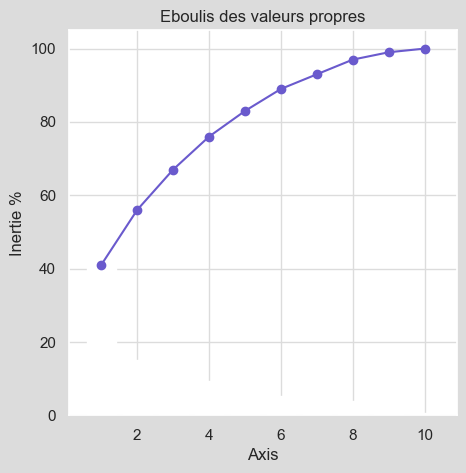

In [34]:
# plot data
plt.figure(figsize=(5,5))
plt.bar(a_list, scree,color=col)
plt.plot(a_list, scree_cum,color='slateblue',marker='o')
plt.xlabel("Axis")
plt.ylabel("Inertie %")
plt.title("Eboulis des valeurs propres")
plt.grid(axis='both', color='gainsboro')
plt.savefig("eboulis.png", bbox_inches='tight')
plt.show(block=False)

#### Nous analyserons plus particulierement les 4 premiers axes, qui permettent de capturer pres de 80% de la variance.

### Analyse des composantes

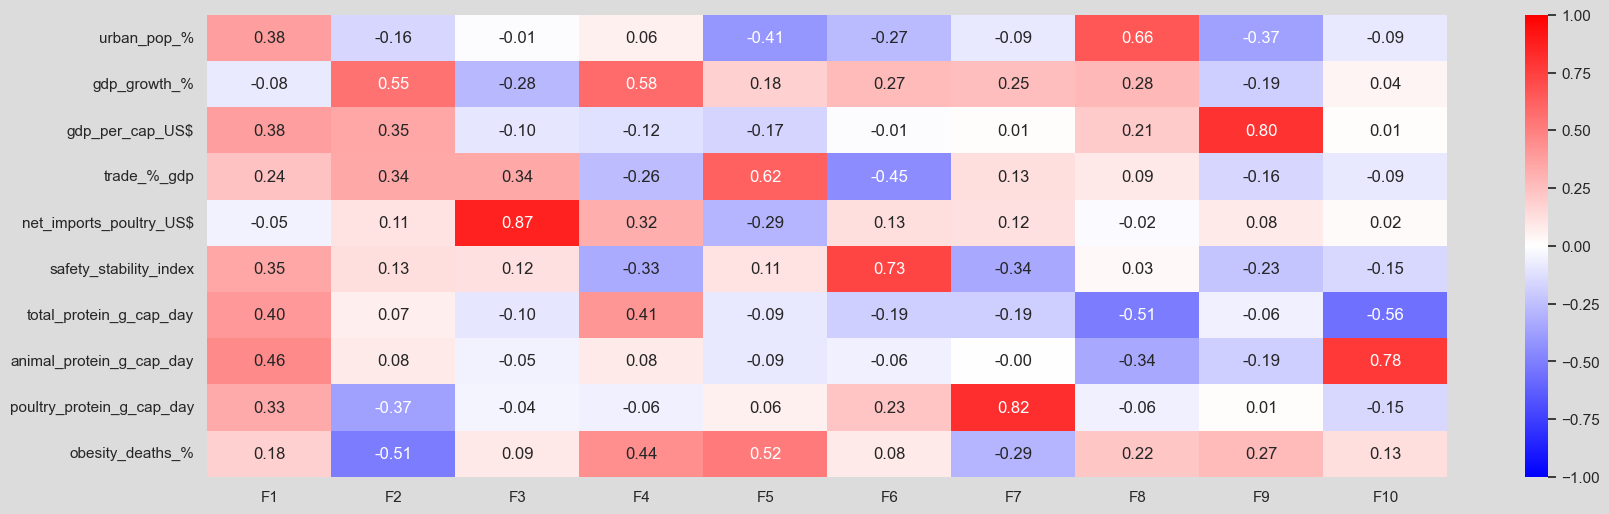

In [35]:
# create components dataframe
acp_components = pd.DataFrame(pca.components_)
acp_components.columns = features
acp_components.index = [f"F{i}" for i in a_list]

# plot heatmap
fig, ax = plt.subplots(figsize=(20, 6))
acp_heatmap = sns.heatmap(acp_components.T.round(2), vmin=-1, vmax=1, annot=True, cmap="bwr", fmt="0.2f")
plt.savefig("acp_heatmap.png")

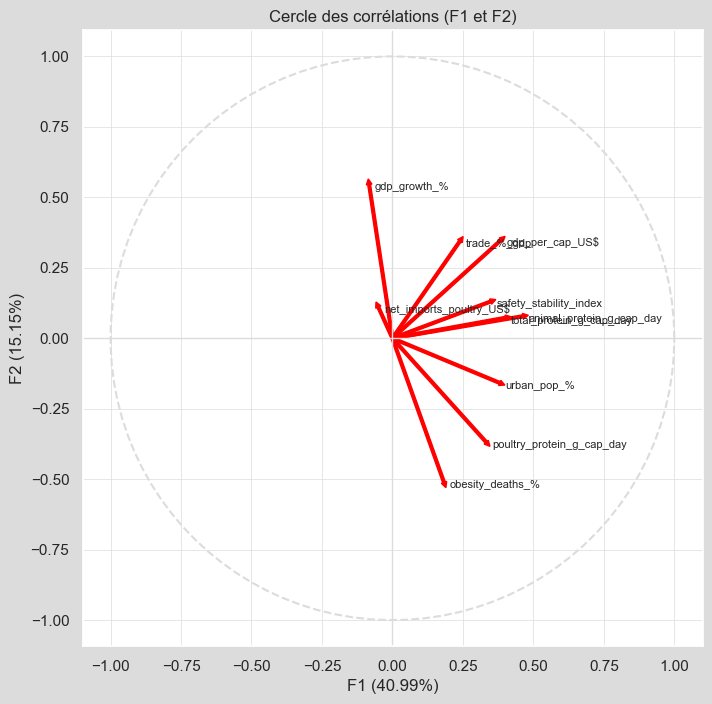

In [37]:
# draw correlation circle for axes 1 and 2
x_y = (0,1)
correlation_graph(pca, x_y, features, col='red')

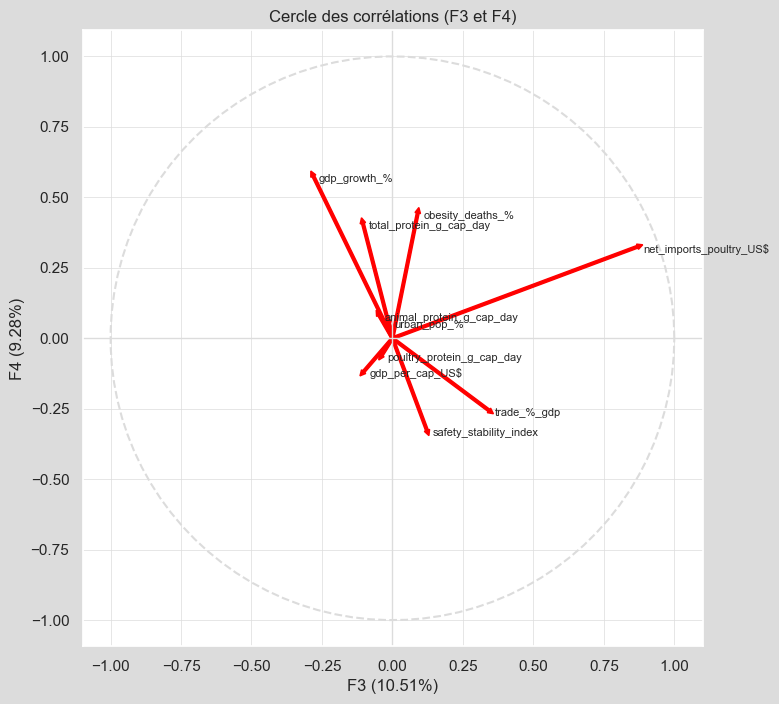

In [38]:
# draw correlation circle for axes 3 and 4
x_y = (2,3)
correlation_graph(pca, x_y, features, col='red')

### Projection des clusters & centroides du K-means a 4 clusters sur le premier plan factoriel

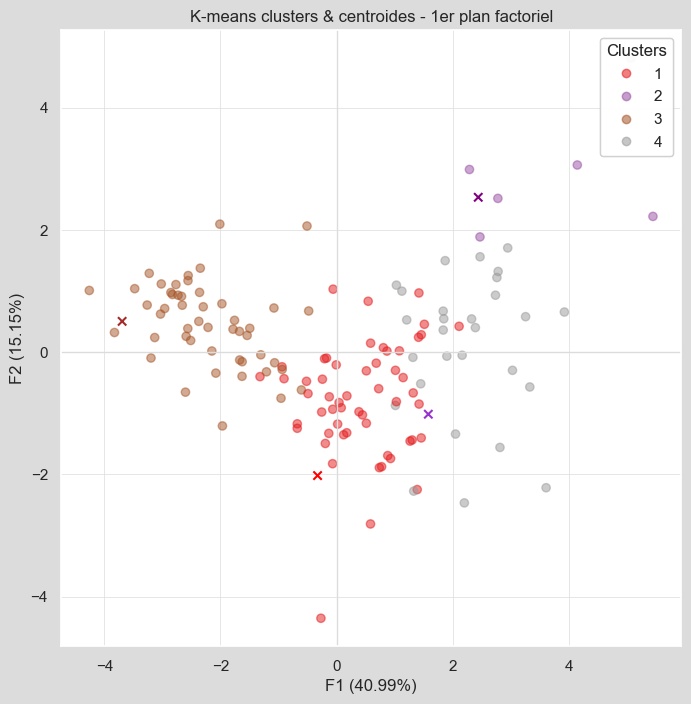

In [39]:
# plot clusters in 1st factorial plane
pca_kmeans = PCA(n_components=4)
pca_kmeans.fit(x_scaled)

x_proj = pca_kmeans.transform(x_scaled)
x_proj = pd.DataFrame(x_proj, columns = ["PC1", "PC2", "PC3", "PC4"])

# use initialised scaler 
centroids_4_scaled = std_scaler.fit_transform(centroids_4)

# use initialised acp 
centroids_4_proj = pca_kmeans.transform(centroids_4_scaled)

# create dataframe
centroids_4_proj = pd.DataFrame(centroids_4_proj,
                              columns = ["F1", "F2", "F3", "F4"], 
                              index=["cluster_0", "cluster_1", "cluster_2", "cluster_3"])

# plot results
fig, ax = plt.subplots(1,1) 
scatter = ax.scatter(x_proj.iloc[:, 0], x_proj.iloc[:, 1], c= clusters['cluster_km_4'], cmap="Set1", alpha =0.5)
ax.scatter(centroids_4_proj.iloc[:, 0], centroids_4_proj.iloc[:, 1],  marker="x",
                      c=['red','purple','brown','darkorchid'])

ax.set_xlabel('F{} ({}%)'.format(1,round(100*pca.explained_variance_ratio_[0],2)))
ax.set_ylabel('F{} ({}%)'.format(2,round(100*pca.explained_variance_ratio_[1],2)))

# plot thicker abscissa and ordinate lines
plt.axvline(x=0, c='gainsboro', lw=1, linestyle='solid')
plt.axhline(y=0, c='gainsboro', lw=1, linestyle='solid')

# produce a legend with the unique colors from the scatter
legend_1 = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="Clusters")
ax.add_artist(legend_1)

ax.set_title("K-means clusters & centroides - 1er plan factoriel")
plt.grid(axis='both', color='gainsboro', lw=0.5)
plt.savefig("Kmeans clusters & centroides - 1er plan factoriel.png", bbox_inches='tight')
plt.show()

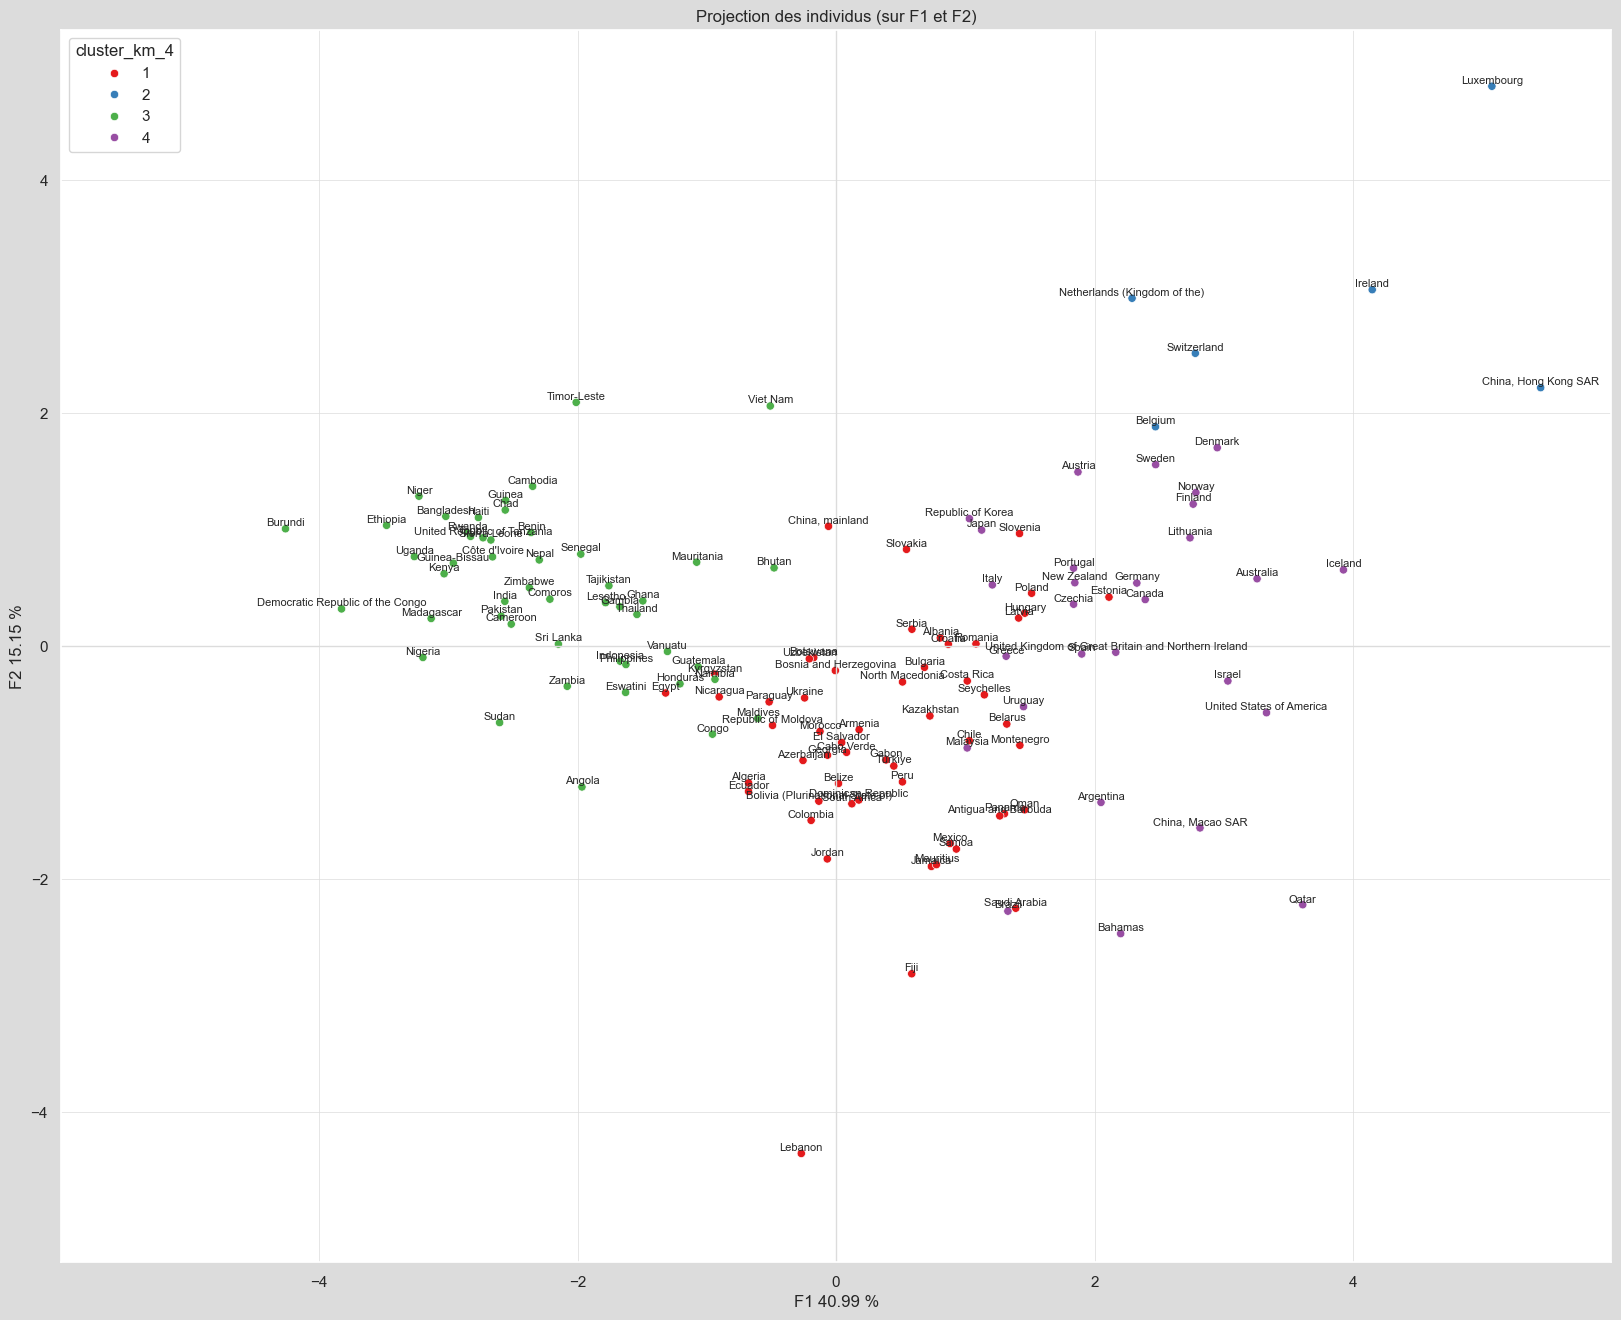

In [40]:
# plot country names on 1st factorial plane with cluster hue
x_y = (0,1)
display_factorial_planes(x_proj, x_y, pca, labels=countries, figsize=(20,16), clusters=clusters['cluster_km_4'],
                         marker="o")

### Projection des clusters & medoides du kmedoids a 4 clusters sur le premier plan factoriel

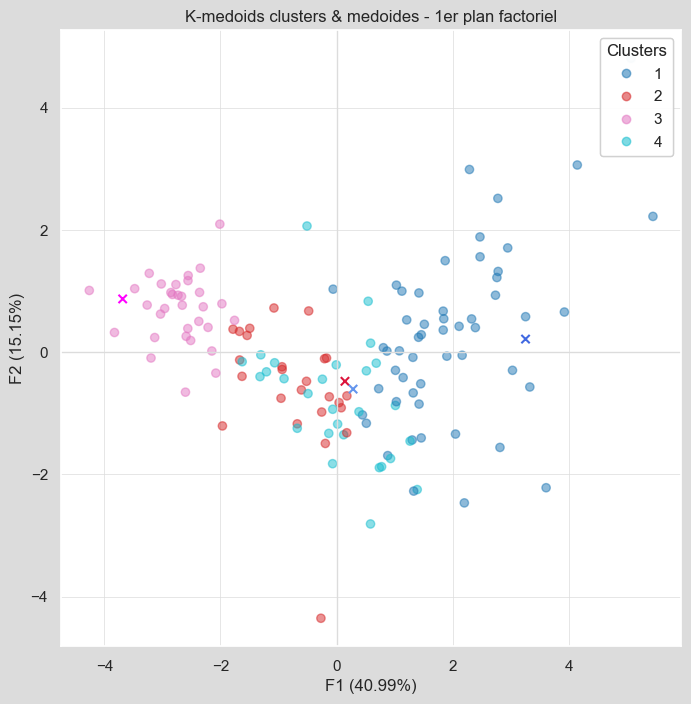

In [41]:
pca_med = PCA(n_components=4)
y_reduced_pca_med = pca_med.fit_transform(y_scaled)

y_proj = pca_kmeans.transform(x_scaled)
y_proj = pd.DataFrame(y_proj, columns = ["PC1", "PC2", "PC3", "PC4"])

# use initialised scaler 
medoids_scaled = std_scaler_med.fit_transform(medoids_4)

# use initialised acp 
medoids_proj = pca_med.transform(medoids_scaled)

# create dataframe
medoids_proj = pd.DataFrame(medoids_proj, 
                              columns = ["F1", "F2", "F3","F4"], 
                              index=["cluster_0", "cluster_1", "cluster_3","cluster_4"])

# plot results
fig, ax = plt.subplots(1,1)
scatter_2 = ax.scatter(y_proj.iloc[:, 0], y_proj.iloc[:, 1], c= clusters['cluster_kmed_4'], cmap="tab10", alpha =0.5)
ax.scatter(medoids_proj.iloc[:, 0], medoids_proj.iloc[:, 1],  marker="x", c=['royalblue','crimson','fuchsia','cornflowerblue'] )

# plot thicker abscissa and ordinate lines
plt.axvline(x=0, c='gainsboro', lw=1, linestyle='solid')
plt.axhline(y=0, c='gainsboro', lw=1, linestyle='solid')

# produce a legend with the unique colors from the scatter
legend_2 = ax.legend(*scatter_2.legend_elements(),
                    loc="upper right", title="Clusters")
ax.add_artist(legend_2)

ax.set_xlabel('F{} ({}%)'.format(1,round(100*pca.explained_variance_ratio_[0],2)))
ax.set_ylabel('F{} ({}%)'.format(2,round(100*pca.explained_variance_ratio_[1],2)))

ax.set_title("K-medoids clusters & medoides - 1er plan factoriel")
plt.grid(axis='both', color='gainsboro', lw=0.5)
plt.savefig("Clusters & Medoides - 1er plan factoriel.png", bbox_inches='tight')
plt.show()

### Tableau croise des differences de clustering Kmeans - Kmedoids

In [42]:
cluster_comp = clusters[['country', 'cluster_dendro','cluster_km_4','cluster_kmed_4']]
km_4_counts = cluster_comp.groupby('cluster_km_4')['country'].nunique().reset_index()
km_4_counts.rename(columns={'country':'km_4_cluster_size'}, inplace=True)
kmed_4_counts = cluster_comp.groupby('cluster_kmed_4')['country'].nunique().reset_index()
kmed_4_counts.rename(columns={'country':'kmed_4_cluster_size'}, inplace=True)
clusters_compared = pd.merge(km_4_counts, kmed_4_counts, how='left', left_on='cluster_km_4', right_on='cluster_kmed_4')
clusters_compared.rename(columns={'cluster_km_4':'cluster_number'}, inplace=True)
clusters_compared.drop(columns=['cluster_kmed_4'], inplace=True)
clusters_compared.to_csv('clusters_compared.csv', index=False, encoding='latin_1')
clusters_compared

,cluster_number,km_4_cluster_size,kmed_4_cluster_size
0,1,55,53
1,2,6,25
2,3,49,32
3,4,28,28


### Inertie totale des pays dans chaque cluster

#### Les pays ayant l'inertie la plus faible dans chaque cluster sont les plus proches du centroide ; on les appelle les parangons. On peut utiliser ces pays pour decrire les caracteristiques moyennes du cluster auxquel ils appartiennent.

In [44]:
# create dataframes to calculate & store distances from cluster points to centroids
distances = pd.DataFrame(x_scaled, columns=data.columns)
distances['country'] = countries
distances_calc = pd.merge(clusters, distances, how='left', right_on='country',left_on='country')

country_inertia = distances_calc[['country','cluster_km_4','urban_pop_%_y', 'gdp_growth_%_y', 'gdp_per_cap_US$_y', 'trade_%_gdp_y',
       'net_imports_poultry_US$_y', 'safety_stability_index_y', 'total_protein_g_cap_day_y',
       'animal_protein_g_cap_day_y', 'poultry_protein_g_cap_day_y',
       'obesity_deaths_%_y']].copy()

country_inertia.rename(columns={'urban_pop_%_y': 'urban_pop_%', 'gdp_growth_%_y':'gdp_growth_%',
                            'gdp_per_cap_US$_y':'gdp_per_cap_US$', 'trade_%_gdp_y':'trade_%_gdp',
                            'net_imports_poultry_US$_y':'net_imports_poultry_US$',
                            'safety_stability_index_y':'safety_stability_index', 
                            'total_protein_g_cap_day_y': 'total_protein_g_cap_day',
                            'animal_protein_g_cap_day_y':'animal_protein_g_cap_day',
                            'poultry_protein_g_cap_day_y':'poultry_protein_g_cap_day',
                            'obesity_deaths_%_y':'obesity_deaths_%'}, inplace=True)

In [45]:
# calculate square of distance from country to its assigned cluster's centroid
country_inertia.loc[country_inertia['cluster_km_4'] == 1, features] = ((np.subtract((country_inertia.loc[country_inertia['cluster_km_4'] == 1, features]),(centroids_km_4.iloc[0])))**2).copy()
country_inertia.loc[country_inertia['cluster_km_4'] == 2, features] = ((np.subtract((country_inertia.loc[country_inertia['cluster_km_4'] == 2, features]),(centroids_km_4.iloc[1])))**2).copy()
country_inertia.loc[country_inertia['cluster_km_4'] == 3, features] = ((np.subtract((country_inertia.loc[country_inertia['cluster_km_4'] == 3, features]),(centroids_km_4.iloc[2])))**2).copy()
country_inertia.loc[country_inertia['cluster_km_4'] == 4, features] = ((np.subtract((country_inertia.loc[country_inertia['cluster_km_4'] == 4, features]),(centroids_km_4.iloc[3])))**2).copy()

In [46]:
# typecast cluster number as string and sum all other numerical columns
country_inertia['cluster_km_4'] = country_inertia['cluster_km_4'].astype(str)
country_inertia['inertia'] = country_inertia.sum(axis=1, numeric_only=True)

# create distance dataframe with reduces number of columns & rename columns
clusters_dist = pd.merge(clusters, country_inertia, how='left', left_on='country',
                         right_on='country')[['country', 'cluster_km_4_x','inertia']]
clusters_dist.rename(columns={'cluster_km_4_x': 'cluster_km_4'}, inplace=True)

# display distances for each country in cluster 1 by decreasing order
clusters_dist_1 = clusters_dist.loc[clusters_dist['cluster_km_4'] == 1].copy()
clusters_dist_1.sort_values(by='inertia', ascending=False, inplace=True)
clusters_dist_1.to_csv('clusters_dist_1.csv', index=False, encoding='latin_1')
clusters_dist_1

,country,cluster_km_4,inertia
19,Lebanon,1,28.787005
86,Samoa,1,14.183464
125,Antigua and Barbuda,1,12.908509
115,Egypt,1,12.627809
60,Seychelles,1,9.445763
118,Fiji,1,9.323796
104,"China, mainland",1,7.414474
12,Jordan,1,6.604315
58,Saudi Arabia,1,6.065622
117,Estonia,1,5.900127


In [47]:
# display distances for each country in cluster 2 by decreasing order
clusters_dist_2 = clusters_dist.loc[clusters_dist['cluster_km_4'] == 2].copy()
clusters_dist_2.sort_values(by='inertia', ascending=False, inplace=True)
clusters_dist_2.to_csv('clusters_dist_2.csv', index=False, encoding='latin_1')
clusters_dist_2

,country,cluster_km_4,inertia
33,Netherlands (Kingdom of the),2,37.017964
134,"China, Hong Kong SAR",2,16.980097
90,Luxembourg,2,14.928370
71,Switzerland,2,8.506366
89,Belgium,2,5.137512
4,Ireland,2,4.724847


In [48]:
# display distances for each country in cluster 3 by decreasing order
clusters_dist_3 = clusters_dist.loc[clusters_dist['cluster_km_4'] == 3].copy()
clusters_dist_3.sort_values(by='inertia', ascending=False, inplace=True)
clusters_dist_3.to_csv('clusters_dist_3.csv', index=False, encoding='latin_1')
clusters_dist_3

,country,cluster_km_4,inertia
25,Maldives,3,13.976560
120,Angola,3,10.921920
84,Viet Nam,3,10.684739
53,Bhutan,3,7.084813
51,Timor-Leste,3,6.468300
94,Sudan,3,6.396201
107,Congo,3,6.300609
38,Niger,3,6.155067
35,Vanuatu,3,5.879650
132,Haiti,3,5.645719


In [49]:
# display distances for each country in cluster 4 by decreasing order
clusters_dist_4 = clusters_dist.loc[clusters_dist['cluster_km_4'] == 4].copy()
clusters_dist_4.sort_values(by='inertia', ascending=False, inplace=True)
clusters_dist_4.to_csv('clusters_dist_4.csv', index=False, encoding='latin_1')
clusters_dist_4

,country,cluster_km_4,inertia
124,Germany,4,35.021827
22,"China, Macao SAR",4,23.379733
81,United States of America,4,18.252812
52,Qatar,4,13.284253
5,Israel,4,11.795336
24,Malaysia,4,11.185189
18,Bahamas,4,11.029917
69,Brazil,4,8.285031
21,Lithuania,4,6.976028
78,United Kingdom of Great Britain and Northern Ireland,4,6.670973


#### Les parangons sont ici respectivement le Salvador pour le cluster 1, le Zimbabwe pour le cluster 2 et le Danemark pour le cluster 3. Le cluster 4 quant a lui ne comporte que 2 pays qui sont donc par definition tous les deux des parangons: bien que differant ici considerablement du point de vue des donnees macro-economiques, alimentaires et demographiques, le Bresil et les USA sont rassembles par leur grande proximite sur le plan des imports nets de poulet (tres negatifs, signalant des export nets tres importants) et qui les mettent donc tres a part des autres pays malgre leurs differences sur d'autres plans (maximisation de la variance inter-clusters malgre leur variance intra-cluster).
#### D'apres les chiffres de l'industrie (ANVOL 2021), les USA et le Bresil sont les deux plus grands exportateurs mondiaux de poulet, devant l'UE. Si l'on considerait l'UE comme un seul pays pour cette analyse, il est probable qu'on la retrouverait dans le meme cluster que ces 2 pays. En pratique, en Europe, ce sont la Pologne et les Pays-Bas qui sont les plus grands exportateurs nets de poulet, mais tres loin derriere les Etats-Unis et le Bresil. Les pays de l'UE ayant par ailleurs bien plus de similarites entre eux, au plan economique notamment, ils se retrouvent donc dans le meme cluster (minimisation de la variance intra-clusters).
#### La fragmentation de l'UE a 27 en autant de pays dans cette analyse nous permet par ailleurs de conserver une granularite necessaire pour affiner les recommandations strategiques.

### Verification des calculs de distance

In [50]:
if (round(country_inertia['inertia'].sum(),3) - round(kmeans_4.inertia_,3)) != 0:
    print("Calculation issue.")
else:
    print("Calculation OK.")

Calculation OK.


In [51]:
# note - there are only 2 data points in cluster 4, so they should be equidistant from the centroid
clusters_dist_4 = clusters_dist.loc[clusters_dist['cluster_km_4'] == 4].copy()
clusters_dist_4.sort_values(by='inertia', ascending=False, inplace=True)
clusters_dist_4

,country,cluster_km_4,inertia
124,Germany,4,35.021827
22,"China, Macao SAR",4,23.379733
81,United States of America,4,18.252812
52,Qatar,4,13.284253
5,Israel,4,11.795336
24,Malaysia,4,11.185189
18,Bahamas,4,11.029917
69,Brazil,4,8.285031
21,Lithuania,4,6.976028
78,United Kingdom of Great Britain and Northern Ireland,4,6.670973


#### Comme il n'y a que 2 points dans le cluster 4, on verifie bien qu'ils sont equidistants du centroide, ce qui est egalement verifiable graphiquement sur leur projection sur le premeir plan factoriel.